In [160]:
import os
from dotenv import load_dotenv
from openai import OpenAI
import base64
import json
import sympy as sp
load_dotenv()
import re
import pymupdf
from IPython.display import Image, display
from langgraph.types import interrupt
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
import re

In [161]:
os.environ["LANGCHAIN_TRACING_V2"] = "false"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "AI_Grading_Agent"

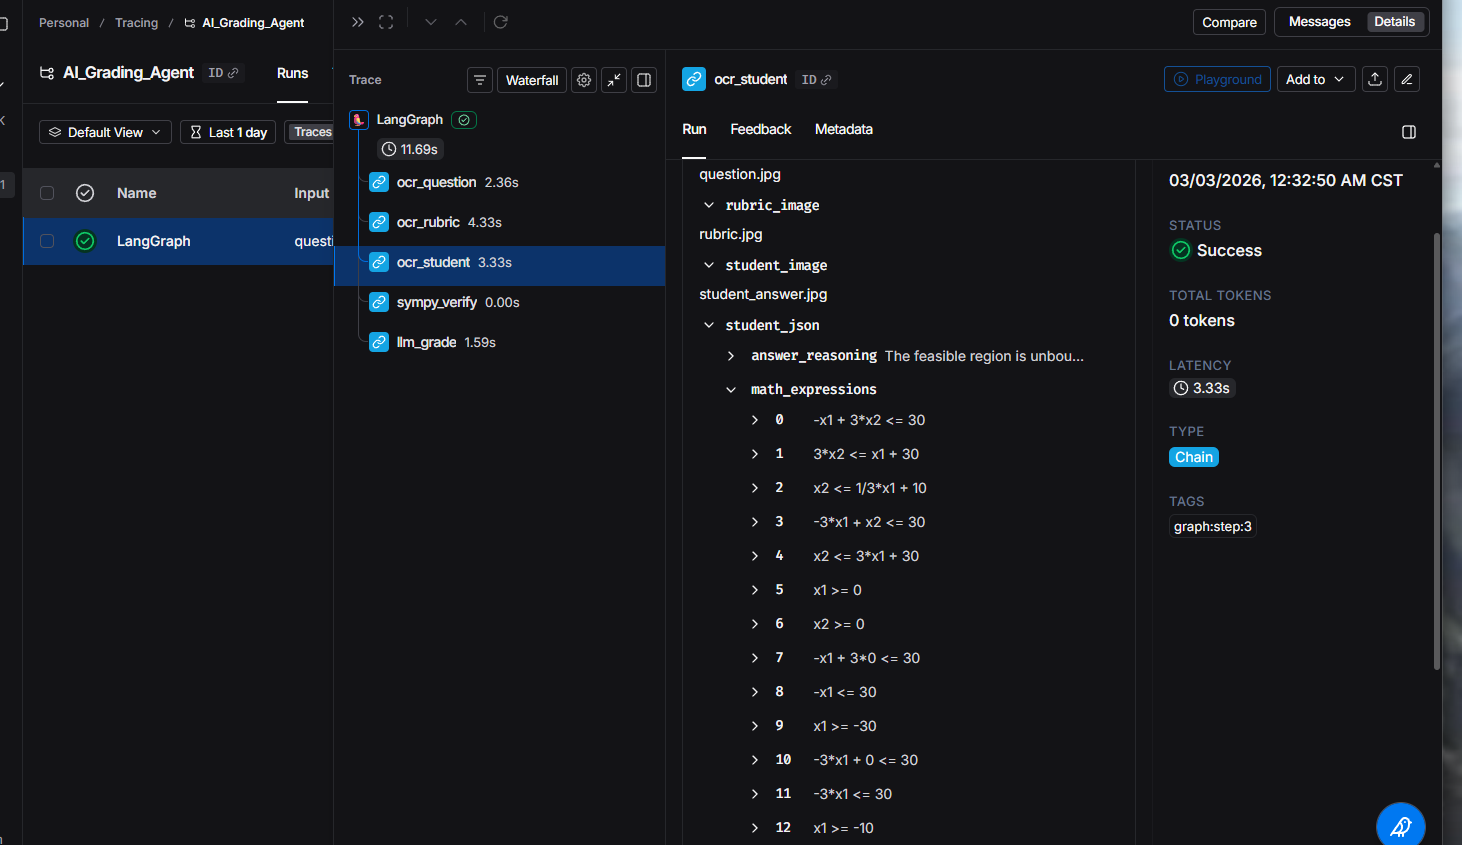

We can monitor our model using LangSmith, which provides a detailed interface to visualize the output, running time, etc.

In [162]:
from typing import TypedDict, Optional, Dict, Any
class GradingState(TypedDict, total=False):
    pdf_path: str
    question_json: Dict[str, Any]
    score: int
    message_last_run: str
    retry_count: int
    max_retries: int
    question_types: str

target json format
```
{
  "question1": {
    "a": {
      "question": "Prove that ...",
      "question_type": [0]
    },
    "b": {
      "question": "Write code to implement ...",
      "question_type": [1]
    }
  },
  "question2": {
    "question": "Plot the function f(x)...",
    "question_type": [2]
  }
}
```
0 is handwriting/LaTex pdf that need to prove/show the problem manually.

1 is the ample code.

2 is graph drawing. During my experience as a TA, I encountered many cases where students needed to draw a coordinate system to illustrate, for example, whether a feasible region was bounded or unbounded.

# Version 1: let ai diagnosis which type of question
Not good! In some cases, gpt 4o mini fails to classify ample as coding homework.
May be we should let us to designate which type of question it is?

In [163]:
def ocr_question(state):
    last_run = state.get("message_last_run")
    if last_run:
        message_last_run = f"Previous parsing result (if exists): {last_run}"
    else:
        message_last_run = ""

    pdf_path = state.get("pdf_path", "HW1_Assignment.pdf") # default as HW1
    state["pdf_path"] = pdf_path

    if not os.path.exists(pdf_path):
        print(f"File not found: {pdf_path}")
        return {"question_json": {}}

    doc = pymupdf.open(pdf_path)
    images = []
    for page in doc:
        pix = page.get_pixmap(dpi=150) # dots per inch, 2400 px
        img_bytes = pix.tobytes("png")

        b64 = base64.b64encode(img_bytes).decode()
        images.append(f"data:image/png;base64,{b64}") # stack all pages of pdf into a single pdf
    doc.close()

    print("-" * 40)
    print("OCR Assignment PDF")
    print("-" * 40)

    content = [
    {
        "type": "input_text",
        "text": f"""
You are an expert in academic assignment parsing.

{message_last_run}

Read the assignment pages and extract ALL questions.

Question type definitions:
0 = mathematical reasoning / proof / feasibility check
1 = coding or modeling task (AMPL, Python, etc.)
2 = plotting / visualization

Return STRICT JSON in the following format:

{{
  "question1": {{
      "a": {{
          "question": "...",
          "question_type": [0,1,2]
      }}
  }},
  "question2": {{
      "question": "...",
      "question_type": [0]
  }}
}}

Rules:
1. Only extract the first level of subquestions.
   Allowed subquestion labels are ONLY:
   (a), (b), (c), (d), ...

2. If a question contains deeper levels like (i), (ii), (iii),
   DO NOT create new JSON entries for them.
   Instead, keep them inside the text of the parent subquestion.

3. The assignment may span multiple pages. Important content such as tables may continue on the next page. You must read all pages before producing the JSON.

Example:

Correct:
"a": {{
    "question": "Check whether the following solutions are feasible:
    (i) ...
    (ii) ...
    (iii) ..."
}}

Incorrect (DO NOT DO THIS):
"a": {{...}},
"i": {{...}},
"ii": {{...}}

4. TABLES (VERY IMPORTANT):
   - If any question includes a table (data table, parameter table, payoff matrix, etc.), you MUST preserve it.
   - Represent the table EXACTLY as monospaced plain text using ASCII formatting inside the "question" string.
   - Keep the SAME row/column order, headers, and all numeric values.
   - Do NOT summarize the table. Do NOT reword table cells.
   - Do NOT drop empty cells; keep placeholders if needed.

   Example table format (ASCII):
   | Col1 | Col2 | Col3 |
   |------|------|------|
   |  1   |  2   |  3   |
   |  4   |  5   |  6   |

5. Output JSON only.
"""
    }
]

    for img in images:
        content.append({
            "type": "input_image",
            "image_url": img
        })


    resp = client.responses.create(
    model="gpt-4o-mini",
    temperature=0,
    input=[
            {
                "role": "user",
                "content": content
            }
        ]
    )

    text = resp.output_text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    print(text)
    print()

    try:
        question_json = json.loads(text)
    except json.JSONDecodeError:
        print("JSON parsing failed")
        return {"question_json": {}}
    return {"question_json": question_json}

In [164]:
def inc_retry(state):
    retry_count = state.get("retry_count", 0) + 1
    return {"retry_count": retry_count}

In [165]:
def route_after_check(state):
    score = state.get("score", 0)
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 3)

    if score < 70 and retry_count < max_retries:
        return "retry"
    return "end"

In [166]:
def ai_check_question(state):
    question = state["question_json"]
    print("-" * 40)
    print("AI Validation Result")
    print("-" * 40)

    if not question or len(question) == 0:
        return {
            "score": 0,
            "message_last_run": "No questions extracted from OCR. Try again."
        }

    content = [
        {
            "type": "input_text",
            "text": f"""
You are an expert in academic assignment validation.

Your task is to evaluate whether the OCR-extracted question JSON is correct and output a score.

Evaluation criteria:
1. Are all questions present?
2. Is the structure correct?
3. Are there obvious OCR mistakes?
4. Is the question_type classification reasonable?

Question type definitions:
0 = mathematical reasoning / proof / feasibility check
1 = coding or modeling task (AMPL, Python, etc.)
2 = plotting / visualization

Return EXACTLY in this format:

Comment: <short explanation>
Score: <number between 0 and 100>

OCR Extracted JSON:
{question}
"""
        }
    ]

    resp = client.responses.create(
        model="gpt-4o-mini",
        temperature=0,
        input=[
            {
                "role": "user",
                "content": content
            }
        ]
    )

    text = resp.output_text.strip()

    print(text)
    print()

    score = 50 # need to redo
    match = re.search(r"Score:\s*(\d+)", text)
    if match:
        score = int(match.group(1))

    return {
        "score": score,
        "message_last_run": text
    }

In [167]:
import pandas as pd

def save_to_json(state):

    print("-" * 40)
    print("Saving question types to JSON")
    print("-" * 40)

    question_json = state.get("question_json", {})
    csv_path = state.get("question_types")
    if csv_path and os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        for _, row in df.iterrows():
            key = str(row["question_id"]).strip().lower()
            q_type = [int(x) for x in str(row["question_type"]).split(",")]
            print("Processing key:", key)
            match = re.match(r"(\d+)([a-z])", key)
            q_num = match.group(1) # question 1
            sub = match.group(2) # problem a for question 1
            q_key = f"question{q_num}"
            if q_key in question_json and sub in question_json[q_key]:
                print("Updating:", q_key, sub, "->", q_type)
                question_json[q_key][sub]["question_type"] = q_type

    with open("questions.json", "w") as f:
        json.dump(question_json, f, indent=2)

    print("JSON saved to questions.json")

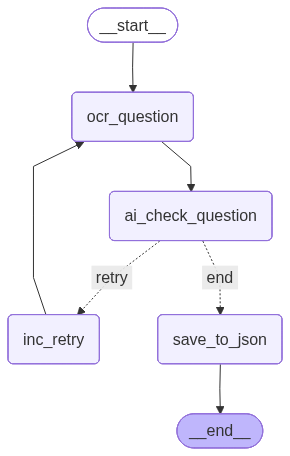

In [168]:
from langgraph.graph import StateGraph, END

builder = StateGraph(GradingState)

builder.add_node("ocr_question", ocr_question)
builder.add_node("ai_check_question", ai_check_question)
builder.add_node("inc_retry", inc_retry)
builder.add_node("save_to_json", save_to_json)

builder.set_entry_point("ocr_question")

builder.add_edge("ocr_question", "ai_check_question")

builder.add_conditional_edges(
    "ai_check_question",
    route_after_check,
    {
        "retry": "inc_retry",
        "end": "save_to_json",
    }
)

builder.add_edge("inc_retry", "ocr_question")
builder.add_edge("save_to_json", END)

graph = builder.compile()

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [169]:
result = graph.invoke({
    "pdf_path": "HW1_Assignment.pdf",
    "use_csv_types": True,
    "question_types": "question_types.csv"
})

----------------------------------------
OCR Assignment PDF
----------------------------------------
{
  "question1": {
    "a": {
      "question": "Use AMPL to model and solve the EV 2-variable example 1.2.1.",
      "question_type": [1]
    },
    "b": {
      "question": "Use AMPL to model and solve the EV 3-variable example 1.4.1.",
      "question_type": [1]
    },
    "c": {
      "question": "Change the required hours of electric wiring and assembly for the hybrid car to be 10 hr. Compare the objective value with 1(b).",
      "question_type": [0]
    }
  },
  "question2": {
    "a": {
      "question": "Write an AMPL model for the investment example 1.5.1.",
      "question_type": [1]
    },
    "b": {
      "question": "Change the investment example 1.5.1 with the cash availability for years 0, 1, and 2 to be 50, 10, and 10 million, respectively. Solve the model by AMPL and give the solutions and objective value.",
      "question_type": [1]
    },
    "c": {
      "question"

In [170]:
with open("questions.json", "r") as f:
    data = json.load(f)
print(json.dumps(data, indent=2))

{
  "question1": {
    "a": {
      "question": "Use AMPL to model and solve the EV 2-variable example 1.2.1.",
      "question_type": [
        0,
        3,
        2
      ]
    },
    "b": {
      "question": "Use AMPL to model and solve the EV 3-variable example 1.4.1.",
      "question_type": [
        1
      ]
    },
    "c": {
      "question": "Change the required hours of electric wiring and assembly for the hybrid car to be 10 hr. Compare the objective value with 1(b).",
      "question_type": [
        2
      ]
    }
  },
  "question2": {
    "a": {
      "question": "Write an AMPL model for the investment example 1.5.1.",
      "question_type": [
        0
      ]
    },
    "b": {
      "question": "Change the investment example 1.5.1 with the cash availability for years 0, 1, and 2 to be 50, 10, and 10 million, respectively. Solve the model by AMPL and give the solutions and objective value.",
      "question_type": [
        1
      ]
    },
    "c": {
      "question